In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For reproducible results
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ==============================
# PROJECT SETTINGS
# ==============================

n_students = 100
n_questions = 500
attempts_per_student = 100

# Number of concepts
n_concepts = 20

print("Students:", n_students)
print("Questions:", n_questions)
print("Concepts:", n_concepts)
print("Attempts per student:", attempts_per_student)

Students: 100
Questions: 500
Concepts: 20
Attempts per student: 100


In [5]:
concepts = [
    "SELECT",
    "WHERE",
    "ORDER BY",
    "GROUP BY",
    "HAVING",
    "JOINS",
    "INNER JOIN",
    "LEFT JOIN",
    "RIGHT JOIN",
    "SUBQUERIES",
    "AGGREGATE FUNCTIONS",
    "UNION",
    "PRIMARY KEY",
    "FOREIGN KEY",
    "NORMALIZATION",
    "INDEXING",
    "VIEWS",
    "STORED PROCEDURES",
    "TRIGGERS",
    "TRANSACTIONS"
]

print("Number of concepts:", len(concepts))

Number of concepts: 20


STEP.3->Create Students and Questions

In [6]:
students = [f"S{i:03d}" for i in range(1, n_students + 1)]
questions = [f"Q{i:03d}" for i in range(1, n_questions + 1)]

print("First 5 students:", students[:5])
print("First 5 questions:", questions[:5])

First 5 students: ['S001', 'S002', 'S003', 'S004', 'S005']
First 5 questions: ['Q001', 'Q002', 'Q003', 'Q004', 'Q005']


4 — Create Question Metadata

In [7]:
# ==============================
# CONCEPT DIFFICULTY RANGES
# ==============================

concept_difficulty = {
    "SELECT": (0.15, 0.40),
    "WHERE": (0.20, 0.45),
    "ORDER BY": (0.20, 0.45),
    "GROUP BY": (0.35, 0.65),
    "HAVING": (0.40, 0.70),
    "JOINS": (0.40, 0.70),
    "INNER JOIN": (0.35, 0.65),
    "LEFT JOIN": (0.40, 0.70),
    "RIGHT JOIN": (0.45, 0.75),
    "SUBQUERIES": (0.55, 0.85),
    "AGGREGATE FUNCTIONS": (0.30, 0.60),
    "UNION": (0.35, 0.65),
    "PRIMARY KEY": (0.20, 0.45),
    "FOREIGN KEY": (0.25, 0.50),
    "NORMALIZATION": (0.50, 0.80),
    "INDEXING": (0.45, 0.75),
    "VIEWS": (0.40, 0.70),
    "STORED PROCEDURES": (0.55, 0.85),
    "TRIGGERS": (0.55, 0.85),
    "TRANSACTIONS": (0.50, 0.80)
}

In [8]:
question_data = []

for q in questions:

    # Randomly select a concept
    concept = np.random.choice(concepts)

    # Get difficulty range for that concept
    min_diff, max_diff = concept_difficulty[concept]

    # Generate difficulty
    difficulty = np.random.uniform(min_diff, max_diff)

    question_data.append({
        "question_id": q,
        "concept": concept,
        "difficulty": round(difficulty, 3)
    })

questions_df = pd.DataFrame(question_data)

questions_df.head()

,question_id,concept,difficulty
0,Q001,INNER JOIN,0.589
1,Q002,NORMALIZATION,0.720
2,Q003,INNER JOIN,0.484
3,Q004,AGGREGATE FUNCTIONS,0.438
4,Q005,GROUP BY,0.393


5 — Create Student Learning Ability

In [9]:
student_ability = {
    student: np.random.uniform(0.3, 0.8)
    for student in students
}

student_ability_df = pd.DataFrame(
    list(student_ability.items()),
    columns=["student_id", "ability"]
)

student_ability_df.head()

,student_id,ability
0,S001,0.370541
1,S002,0.503196
2,S003,0.461995
3,S004,0.343463
4,S005,0.616620


In [10]:
# ==============================
# INITIAL KNOWLEDGE
# ==============================

knowledge = {
    student: {
        concept: np.random.uniform(0.2, 0.5)
        for concept in concepts
    }
    for student in students
}

# Track when each concept was last practiced
last_practice = {
    student: {
        concept: 0.0
        for concept in concepts
    }
    for student in students
}

print("Initial JOIN knowledge of S001:",
      round(knowledge["S001"]["JOINS"], 3))


Initial JOIN knowledge of S001: 0.356


6 — Generate Student Interactions







7 — Add Forgetting Behavior

In [11]:
# ==============================
# GENERATE INTERACTIONS
# ==============================

interactions = []

for student in students:

    current_time = 0.0

    for attempt in range(1, attempts_per_student + 1):

        # --------------------------------
        # 1. Select a random question
        # --------------------------------
        question = np.random.choice(questions)

        q_info = questions_df[
            questions_df["question_id"] == question
        ].iloc[0]

        concept = q_info["concept"]
        difficulty = q_info["difficulty"]

        # --------------------------------
        # 2. Generate time gap
        # --------------------------------
        time_gap = np.random.exponential(scale=1.5)

        current_time += time_gap

        # --------------------------------
        # 3. Calculate forgetting
        # --------------------------------
        days_since_practice = (
            current_time - last_practice[student][concept]
        )

        current_knowledge = knowledge[student][concept]

        # Forgetting rate
        forgetting_rate = 0.015

        # Knowledge decreases with time
        forgotten_amount = (
            forgetting_rate * days_since_practice
        )

        current_knowledge -= forgotten_amount

        current_knowledge = np.clip(
            current_knowledge, 0, 1
        )

        # --------------------------------
        # 4. Calculate probability
        # --------------------------------
        ability = student_ability[student]

        probability = (
            0.45 * current_knowledge
            + 0.30 * ability
            + 0.25 * (1 - difficulty)
        )

        probability = np.clip(
            probability, 0.05, 0.95
        )

        # --------------------------------
        # 5. Generate answer
        # --------------------------------
        correct = np.random.binomial(
            1, probability
        )

        # --------------------------------
        # 6. Update knowledge
        # --------------------------------
        if correct == 1:

            # Learning improvement
            current_knowledge += 0.06

        else:

            # Small decrease after wrong answer
            current_knowledge -= 0.025

        current_knowledge = np.clip(
            current_knowledge, 0, 1
        )

        # --------------------------------
        # 7. Save updated knowledge
        # --------------------------------
        knowledge[student][concept] = current_knowledge

        last_practice[student][concept] = current_time

        # --------------------------------
        # 8. Save interaction
        # --------------------------------
        interactions.append({

            "student_id": student,

            "attempt": attempt,

            "question_id": question,

            "concept": concept,

            "difficulty": difficulty,

            "correct": correct,

            "time_gap_days": round(time_gap, 3),

            "days_since_practice": round(
                days_since_practice, 3
            ),

            "timestamp": round(
                current_time, 3
            ),

            # Hidden simulation value
            "knowledge_state": round(
                current_knowledge, 4
            )

        })

interactions_df = pd.DataFrame(interactions)

print("Dataset shape:", interactions_df.shape)

Dataset shape: (10000, 10)


8-save the dataset

In [12]:
interactions_df.to_csv(
    "learntwin_student_interactions.csv",
    index=False
)

questions_df.to_csv(
    "learntwin_questions.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


In [13]:
df = pd.read_csv("learntwin_student_interactions.csv")

df.head()

,student_id,attempt,question_id,concept,difficulty,correct,time_gap_days,days_since_practice,timestamp,knowledge_state
0,S001,1,Q043,RIGHT JOIN,0.724,0,3.007,3.007,3.007,0.3574
1,S001,2,Q452,RIGHT JOIN,0.577,0,1.471,1.471,4.478,0.3103
2,S001,3,Q022,UNION,0.499,1,1.675,6.154,6.154,0.3849
3,S001,4,Q007,WHERE,0.380,1,0.563,6.717,6.717,0.4015
4,S001,5,Q114,STORED PROCEDURES,0.598,1,2.683,9.400,9.400,0.1345


In [14]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (10000, 10)

Columns:
Index(['student_id', 'attempt', 'question_id', 'concept', 'difficulty',
       'correct', 'time_gap_days', 'days_since_practice', 'timestamp',
       'knowledge_state'],
      dtype='str')

Data types:
student_id                 str
attempt                  int64
question_id                str
concept                    str
difficulty             float64
correct                  int64
time_gap_days          float64
days_since_practice    float64
timestamp              float64
knowledge_state        float64
dtype: object


In [15]:
df.isnull().sum()


student_id             0
attempt                0
question_id            0
concept                0
difficulty             0
correct                0
time_gap_days          0
days_since_practice    0
timestamp              0
knowledge_state        0
dtype: int64

In [16]:
overall_accuracy = df["correct"].mean()

print("Overall accuracy:", round(overall_accuracy, 3))

Overall accuracy: 0.307


In [17]:
concept_accuracy = (
    df.groupby("concept")["correct"]
    .mean()
    .sort_values()
)

concept_accuracy

concept
SUBQUERIES             0.234450
STORED PROCEDURES      0.251163
NORMALIZATION          0.257903
JOINS                  0.258123
TRANSACTIONS           0.259939
TRIGGERS               0.262729
INDEXING               0.268559
GROUP BY               0.283898
INNER JOIN             0.291480
HAVING                 0.301059
LEFT JOIN              0.302857
UNION                  0.311897
VIEWS                  0.320908
RIGHT JOIN             0.330595
FOREIGN KEY            0.337423
AGGREGATE FUNCTIONS    0.341004
ORDER BY               0.348928
PRIMARY KEY            0.363636
WHERE                  0.373377
SELECT                 0.376206
Name: correct, dtype: float64

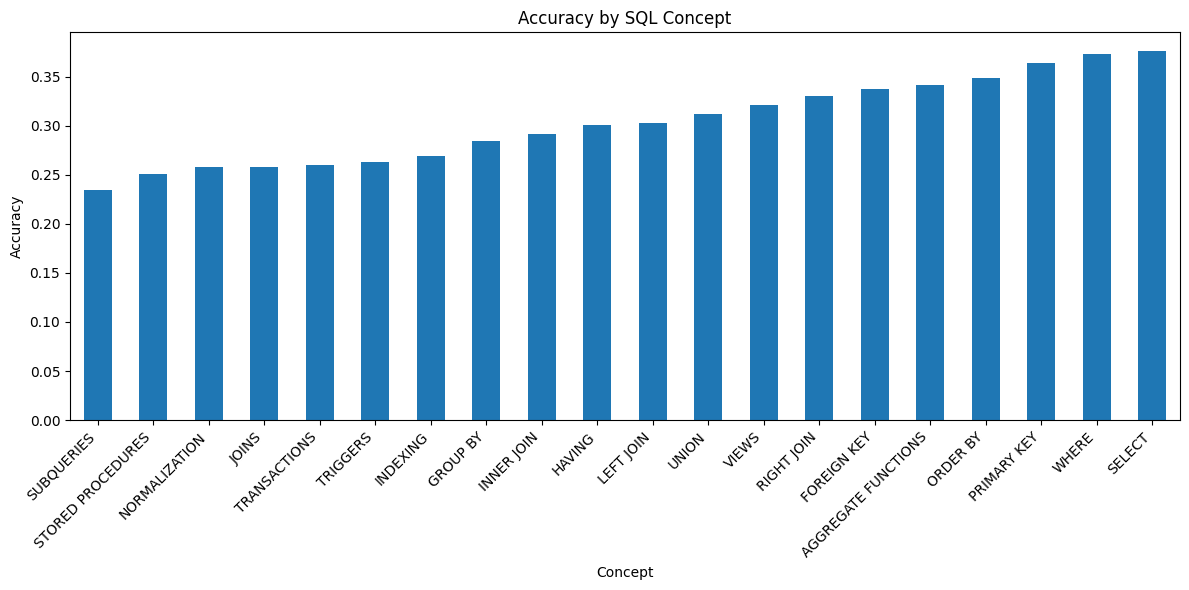

In [18]:
plt.figure(figsize=(12, 6))

concept_accuracy.plot(kind="bar")

plt.title("Accuracy by SQL Concept")
plt.xlabel("Concept")
plt.ylabel("Accuracy")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


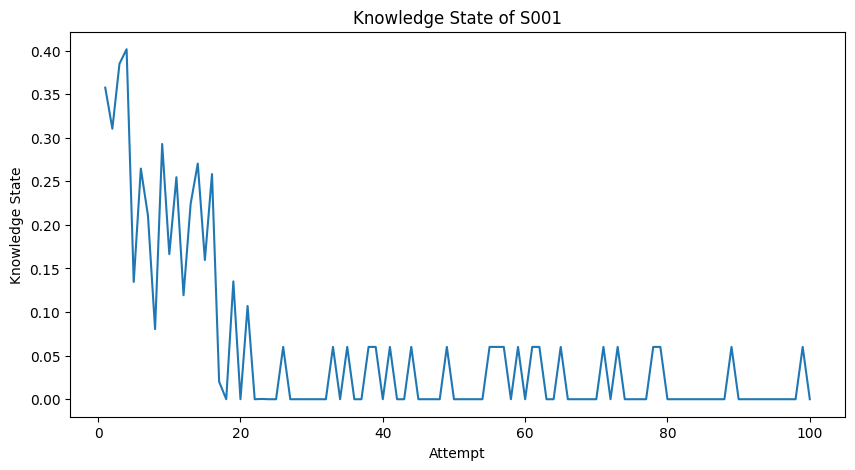

In [19]:
student_id = "S001"

student_data = df[
    df["student_id"] == student_id
]

plt.figure(figsize=(10, 5))

plt.plot(
    student_data["attempt"],
    student_data["knowledge_state"]
)

plt.title(f"Knowledge State of {student_id}")
plt.xlabel("Attempt")
plt.ylabel("Knowledge State")

plt.show()

Previous knowledge
        ↓
Forgetting based on time gap
        ↓
Current knowledge
        ↓
Question difficulty + student ability
        ↓
Correct / Wrong
        ↓
Learning improvement
        ↓
Updated knowledge